# Prozesssimulation (Bachelor)
## Übung 3: Gekoppelte gewöhnliche Differentialgleichungssysteme
### Simulation eines fallenden Metallpartikels

In dieser Übung werden wir schrittweise ein gekoppeltes Differentialgleichungssystem (ODE-System) aufbauen, um die Physik eines heißen, schmelzflüssigen Metallpartikels zu simulieren, das durch ein kühles Gas fällt. Wir werden die Geschwindigkeit, die Fallstrecke und die Temperatur des Partikels über die Zeit und den Weg berechnen.

**Ziel:** Schrittweise Implementierung eines komplexen, gekoppelten physikalischen Modells mit `scipy.integrate.solve_ivp` und Visualisierung der Ergebnisse.

## Benötigte Bibliotheken und Grundeinstellungen

Zuerst importieren wir die notwendigen Python-Bibliotheken und definieren die Konstanten, die wir in allen Schritten verwenden werden.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Globale Einstellungen für die Plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# --- Globale Konstanten ---
# Bezeichnungen wie im Skript: Index _p = Partikel, Index _f = Fluid (Gas)

# Partikeleigenschaften (angenommen Stahl)
d_p = 500e-6      # Partikeldurchmesser [m]
rho_p = 7850      # Partikeldichte [kg/m^3]

# Gas- und Umgebungs-Eigenschaften (Stickstoff)
T_f = 293.15      # Gastemperatur (Umgebung) [K]

# Physikalische Konstanten
g = 9.81          # Erdbeschleunigung [m/s^2]

## Schritt 1: Isotherme Bewegung

**Ziel:** Implementierung der grundlegenden Bewegungsgleichungen unter der Annahme, dass das Partikel und das Gas die gleiche Temperatur haben. Die Stoffwerte sind konstant.

**Physikalisches Modell** (Skript, Abschnitt 3.2.1):
$$
\frac{dv}{dt} = g \left(1 - \frac{\rho_f}{\rho_p}\right) - \frac{3 \cdot c_w \cdot \rho_f}{4 \cdot d_p \cdot \rho_p} v^2
$$
$$
\frac{ds}{dt} = v
$$
Der Widerstandsbeiwert $c_w$ wird nach der Schiller-Naumann-Korrelation berechnet:
$$
c_w = \frac{24}{Re_p}\left(1 + 0{,}15\, Re_p^{0{,}687}\right), \qquad Re_p = \frac{\rho_f\, v\, d_p}{\eta_f}
$$

**Bezeichnungen im Code:** $\eta_f$ (dynamische Viskosität) → `eta_f_...`, $Re_p$ → `Re_p`, $c_w$ → `c_w`. Der Zustandsvektor ist `y = [v, s]`.

### Implementierung

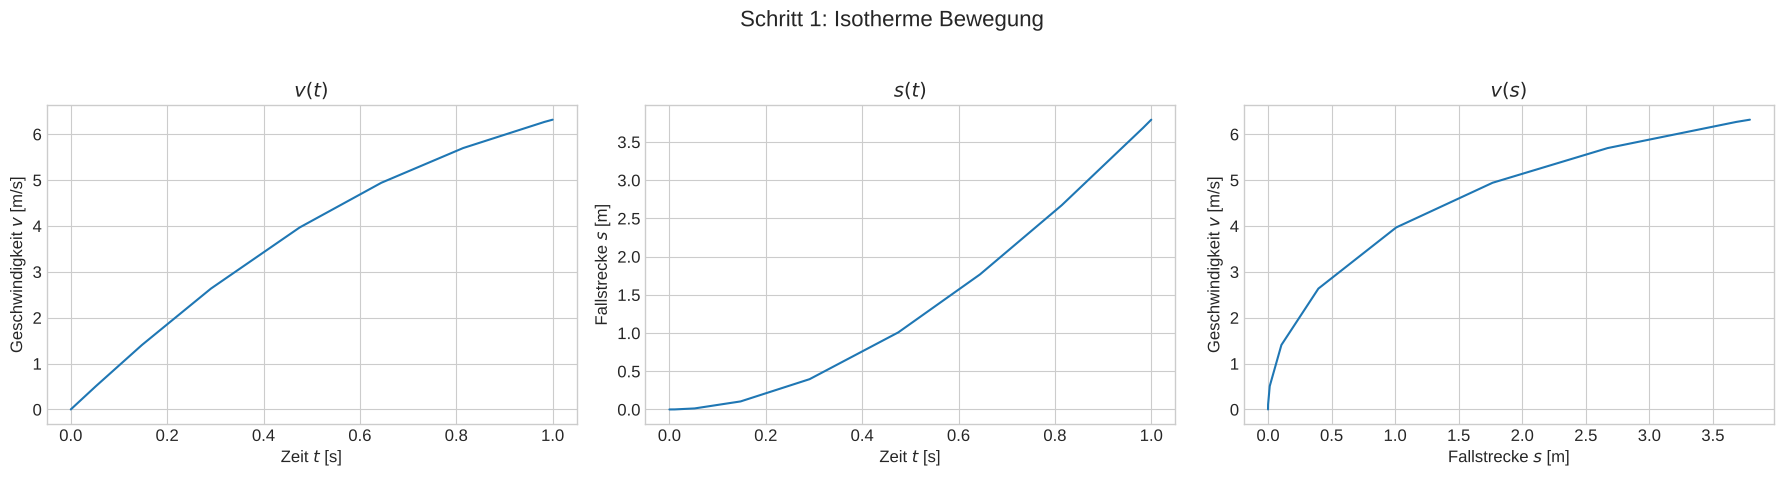

In [2]:
# --- Konstanten für Schritt 1 ---
rho_f_const = 1.153     # Gasdichte bei T_f [kg/m^3]
eta_f_const = 1.76e-5   # Dynamische Viskosität des Gases bei T_f [Pa*s]

# --- ODE-System für Schritt 1 ---
def model_step1(t, y):
    v, s = y

    Re_p = rho_f_const * abs(v) * d_p / eta_f_const
    if Re_p > 0:
        c_w = (24 / Re_p) * (1 + 0.15 * Re_p**0.687)
    else:
        c_w = 0

    dv_dt = ##########
    ds_dt = v

    return [dv_dt, ds_dt]

# --- Simulation ---
y0_step1 = [0, 0]
t_span = [0, 1]

sol_step1 = solve_ivp(##########, t_span, y0_step1, rtol=1e-6)

# --- Plotten der Ergebnisse ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Schritt 1: Isotherme Bewegung', fontsize=16)

# v(t)
axs[0].plot(sol_step1.t, sol_step1.y[0])
axs[0].set_xlabel('Zeit $t$ [s]')
axs[0].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0].set_title('$v(t)$')

# s(t)
axs[1].plot(sol_step1.t, sol_step1.y[1])
axs[1].set_xlabel('Zeit $t$ [s]')
axs[1].set_ylabel('Fallstrecke $s$ [m]')
axs[1].set_title('$s(t)$')

# v(s)
axs[2].plot(sol_step1.y[1], sol_step1.y[0])
axs[2].set_xlabel('Fallstrecke $s$ [m]')
axs[2].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[2].set_title('$v(s)$')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Schritt 2: Temperaturabhängige Stoffwerte (isotherm, heiß)

**Ziel:** Das Partikel hat eine konstant hohe Temperatur. Wir berücksichtigen den Einfluss dieser Temperatur auf die Gaseigenschaften (Dichte, Viskosität) in der Partikelumgebung.

**Physikalisches Modell:**
Die Gleichungen sind dieselben wie in Schritt 1, aber die Stoffwerte $\rho_f$ und $\eta_f$ für den Widerstand (und damit $Re_p$) werden bei der konstanten Partikeltemperatur $T_p$ berechnet. Für den Auftrieb wird die Gasdichte bei Umgebungstemperatur $T_f$ verwendet.

$$\frac{dv}{dt} = g \left(1 - \frac{\rho_f(T_f)}{\rho_p}\right) - \frac{3 \cdot c_w(Re_p) \cdot \rho_f(T_p)}{4 \cdot d_p \cdot \rho_p} v^2
\qquad \text{mit} \qquad Re_p = \frac{\rho_f(T_p)\, v\, d_p}{\eta_f(T_p)}
$$

$$
\frac{ds}{dt} = v
$$

**Bezeichnungen im Code:** $\rho_f(T_p)$ → `rho_f_Tp`, $\eta_f(T_p)$ → `eta_f_Tp`, $\rho_f(T_f)$ → `rho_f_Tf`.

### Implementierung

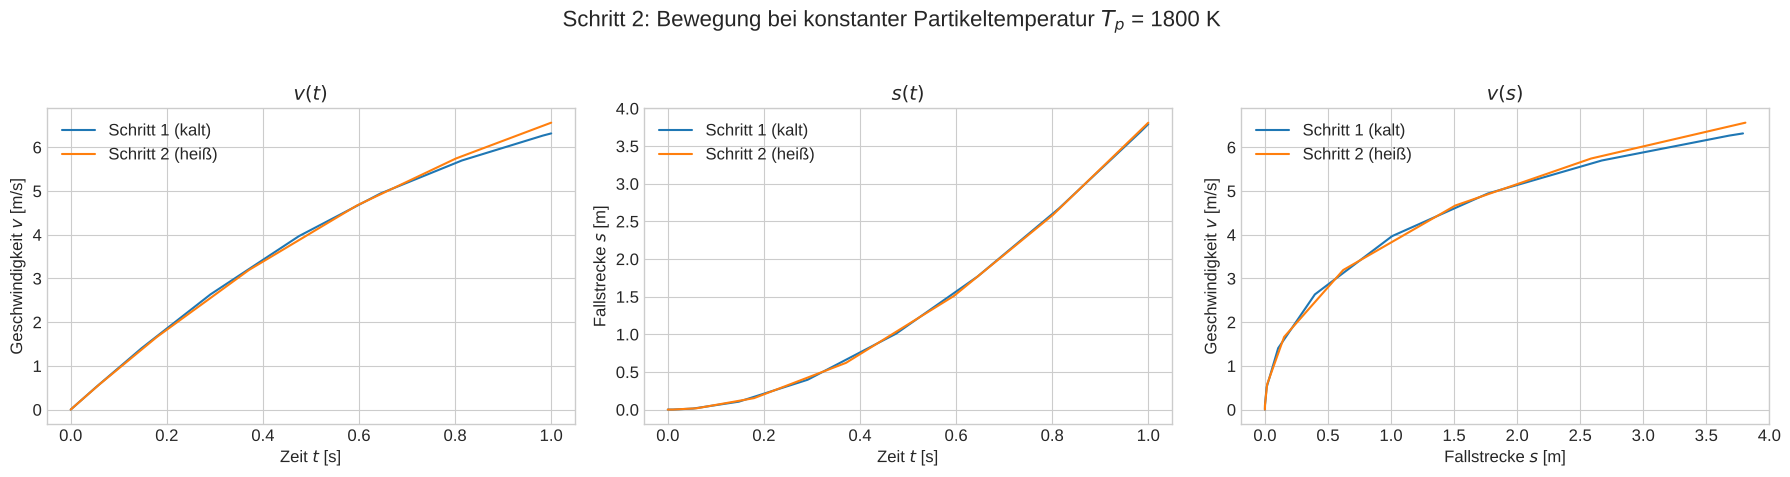

In [3]:
# --- Funktionen für temperaturabhängige Stoffwerte (Stickstoff) ---
def rho_gas(T):   # Dichte [kg/m^3] (ideales Gas)
    R_specific = 296.8
    p_atm = 101325
    return p_atm / (R_specific * T)

def eta_gas(T):   # Dynamische Viskosität [Pa*s]
    return -1.0725e-11 * T**2 + 4.9085e-08 * T + 4.1951e-06

# --- Konstante Partikeltemperatur für Schritt 2 ---
T_p_const = 1800  # [K]

# --- ODE-System für Schritt 2 ---
def model_step2(t, y):
    v, s = y

    rho_f_Tp = ##########
    eta_f_Tp = ##########

    Re_p = rho_f_Tp * abs(v) * d_p / eta_f_Tp
    if Re_p > 0:
        c_w = (24 / Re_p) * (1 + 0.15 * Re_p**0.687)
    else:
        c_w = 0

    rho_f_Tf = rho_gas(T_f)

    dv_dt = g * (1 - rho_f_Tf / rho_p) - (3 * c_w * rho_f_Tp) / (4 * d_p * rho_p) * v**2
    ds_dt = v

    return [dv_dt, ds_dt]

# --- Simulation ---
y0_step2 = [0, 0]
sol_step2 = solve_ivp(##########, t_span, y0_step2, rtol=1e-6)

# --- Plotten der Ergebnisse ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Schritt 2: Bewegung bei konstanter Partikeltemperatur $T_p$ = {T_p_const} K', fontsize=16)

# v(t)
axs[0].plot(sol_step1.t, sol_step1.y[0], label='Schritt 1 (kalt)')
axs[0].plot(sol_step2.t, sol_step2.y[0], label='Schritt 2 (heiß)')
axs[0].set_xlabel('Zeit $t$ [s]')
axs[0].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0].set_title('$v(t)$')
axs[0].legend()

# s(t)
axs[1].plot(sol_step1.t, sol_step1.y[1], label='Schritt 1 (kalt)')
axs[1].plot(sol_step2.t, sol_step2.y[1], label='Schritt 2 (heiß)')
axs[1].set_xlabel('Zeit $t$ [s]')
axs[1].set_ylabel('Fallstrecke $s$ [m]')
axs[1].set_title('$s(t)$')
axs[1].legend()

# v(s)
axs[2].plot(sol_step1.y[1], sol_step1.y[0], label='Schritt 1 (kalt)')
axs[2].plot(sol_step2.y[1], sol_step2.y[0], label='Schritt 2 (heiß)')
axs[2].set_xlabel('Fallstrecke $s$ [m]')
axs[2].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[2].set_title('$v(s)$')
axs[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Schritt 3: Gekoppeltes System mit Abkühlung

**Ziel:** Die Partikeltemperatur ist nun eine Variable. Wir fügen die Energiebilanz als dritte ODE hinzu und lösen das gekoppelte System. Der Zustandsvektor ist `y = [v, T_p, s]`.

**Physikalisches Modell** (Skript, Abschnitt 3.3):

$$
\frac{dv}{dt} = g \left(1 - \frac{\rho_f(T_f)}{\rho_p}\right) - \frac{3 \cdot c_w(Re_p) \cdot \rho_f(T_p)}{4 \cdot d_p \cdot \rho_p} v^2
$$
$$
\frac{dT_p}{dt} = - \frac{6\,\alpha(Re_{film}, Pr_{film})}{\rho_p \cdot c_{p,p} \cdot d_p} (T_p - T_f)
$$
$$
\frac{ds}{dt} = v
$$
Der Wärmeübergangskoeffizient $\alpha$ wird nach der Ranz-Marshall-Korrelation berechnet. Die Stoffwerte werden dabei bei der Filmtemperatur $T_{film} = (T_p + T_f)/2$ ausgewertet:
$$
Nu_{film} = \frac{\alpha\, d_p}{\lambda_f} = 2{,}0 + 0{,}6\, Re_{film}^{1/2}\, Pr_{film}^{1/3}
$$

**Bezeichnungen im Code:** $c_{p,p}$ → `c_p_p`, $c_{p,f}$ → `c_p_gas(T)`, $\lambda_f$ → `lambda_gas(T)`, $T_{film}$ → `T_film`, $Re_{film}$, $Pr_{film}$, $Nu_{film}$ → `Re_film`, `Pr_film`, `Nu_film`.

### Implementierung

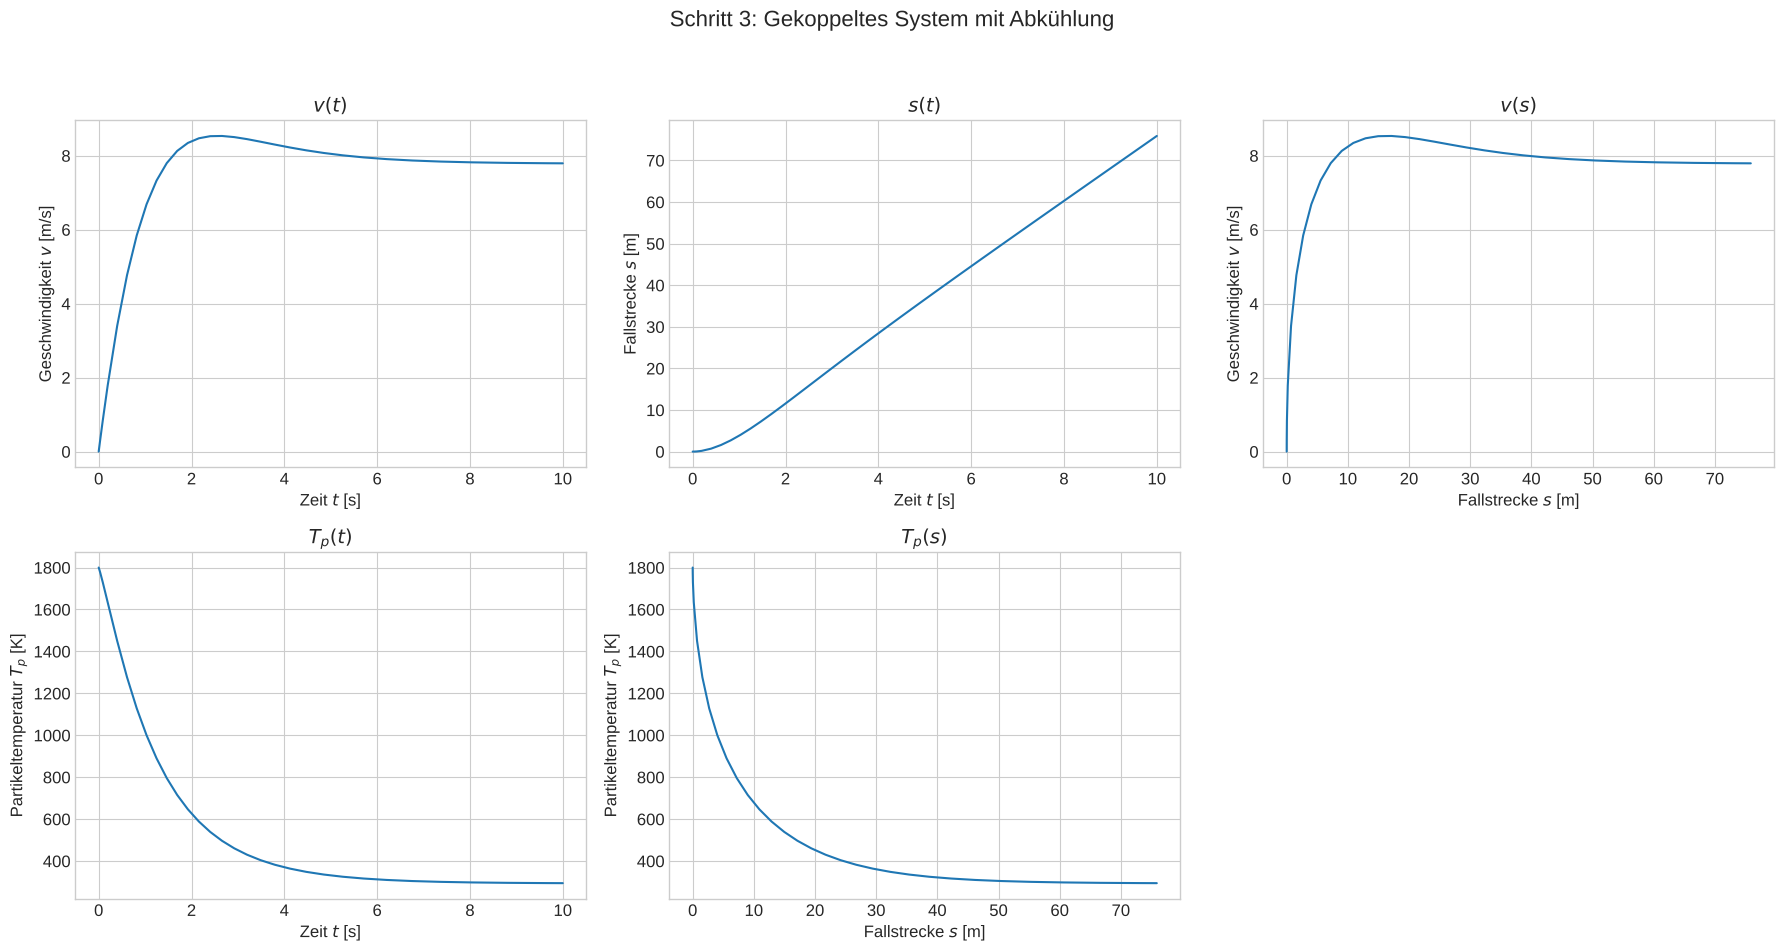

In [4]:
# --- Zusätzliche Stoffwert-Funktionen ---
def lambda_gas(T):  # Wärmeleitfähigkeit [W/(m*K)]
    return 1.4024e-08 * T**2 + 2.0592e-05 * T + 2.4042e-03

def c_p_gas(T):     # Spezifische Wärmekapazität des Gases [J/(kg*K)]
    return 1.9442e-04 * T**2 - 1.5457e-01 * T + 1.0599e+03

# --- Partikel-Wärmekapazität ---
c_p_p = 600  # [J/(kg*K)]

# --- ODE-System für Schritt 3 ---
def model_step3(t, y):
    v, T_p, s = y

    # Impulsbilanz (Stoffwerte bei T_p)
    rho_f_Tp = rho_gas(T_p)
    eta_f_Tp = eta_gas(T_p)
    Re_p = rho_f_Tp * abs(v) * d_p / eta_f_Tp
    if Re_p > 0:
        c_w = (24 / Re_p) * (1 + 0.15 * Re_p**0.687)
    else:
        c_w = 0
    rho_f_Tf = rho_gas(T_f)
    dv_dt = g * (1 - rho_f_Tf / rho_p) - (3 * c_w * rho_f_Tp) / (4 * d_p * rho_p) * v**2

    # Energiebilanz (Stoffwerte bei Filmtemperatur)
    T_film = ##########
    Re_film = rho_gas(T_film) * abs(v) * d_p / eta_gas(T_film)
    Pr_film = c_p_gas(T_film) * eta_gas(T_film) / lambda_gas(T_film)
    Nu_film = 2.0 + 0.6 * Re_film**0.5 * Pr_film**(1/3)
    alpha = Nu_film * lambda_gas(T_film) / d_p
    dTp_dt = ##########

    # Wegbilanz
    ds_dt = v

    return [dv_dt, dTp_dt, ds_dt]

# --- Simulation ---
y0_step3 = [0, 1800, 0]   # [v_0, T_p,0, s_0]
t_span_long = [0, 10]

sol_step3 = solve_ivp(##########, t_span_long, y0_step3, rtol=1e-6)

# --- Plotten der Ergebnisse ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Schritt 3: Gekoppeltes System mit Abkühlung', fontsize=16)

# v(t)
axs[0, 0].plot(sol_step3.t, sol_step3.y[0])
axs[0, 0].set_xlabel('Zeit $t$ [s]')
axs[0, 0].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0, 0].set_title('$v(t)$')

# s(t)
axs[0, 1].plot(sol_step3.t, sol_step3.y[2])
axs[0, 1].set_xlabel('Zeit $t$ [s]')
axs[0, 1].set_ylabel('Fallstrecke $s$ [m]')
axs[0, 1].set_title('$s(t)$')

# v(s)
axs[0, 2].plot(sol_step3.y[2], sol_step3.y[0])
axs[0, 2].set_xlabel('Fallstrecke $s$ [m]')
axs[0, 2].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0, 2].set_title('$v(s)$')

# T_p(t)
axs[1, 0].plot(sol_step3.t, sol_step3.y[1])
axs[1, 0].set_xlabel('Zeit $t$ [s]')
axs[1, 0].set_ylabel('Partikeltemperatur $T_p$ [K]')
axs[1, 0].set_title('$T_p(t)$')

# T_p(s)
axs[1, 1].plot(sol_step3.y[2], sol_step3.y[1])
axs[1, 1].set_xlabel('Fallstrecke $s$ [m]')
axs[1, 1].set_ylabel('Partikeltemperatur $T_p$ [K]')
axs[1, 1].set_title('$T_p(s)$')

# Leerer Plot für Symmetrie
axs[1, 2].axis('off')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Schritt 4: System mit Erstarrung

**Ziel:** Modellierung der latenten Wärme, die bei der Erstarrung freigesetzt wird, durch eine effektive Wärmekapazität.

**Physikalisches Modell** (Skript, Abschnitt 3.2.4):
Die Gleichungen sind dieselben wie in Schritt 3, aber in der Energiebilanz wird die konstante Wärmekapazität $c_{p,p}$ durch die temperaturabhängige effektive Wärmekapazität $c_{p,eff}(T_p)$ ersetzt.

$$c_{p,eff}(T_p) = \begin{cases}
c_{p,liq} & \text{für } T_p > T_{liq} \\
c_{p,sol} + \dfrac{\Delta h_s}{T_{liq} - T_{sol}} & \text{für } T_{sol} \le T_p \le T_{liq} \\
c_{p,sol} & \text{für } T_p < T_{sol}
\end{cases}
$$

**Bezeichnungen im Code:** Liquidustemperatur $T_{liq}$ → `T_liq`, Solidustemperatur $T_{sol}$ → `T_sol`, spezifische Erstarrungsenthalpie $\Delta h_s$ → `dh_s`, $c_{p,liq}$ / $c_{p,sol}$ → `c_p_liq` / `c_p_sol`, $c_{p,eff}$ → `c_p_eff(T_p)`.

### Implementierung

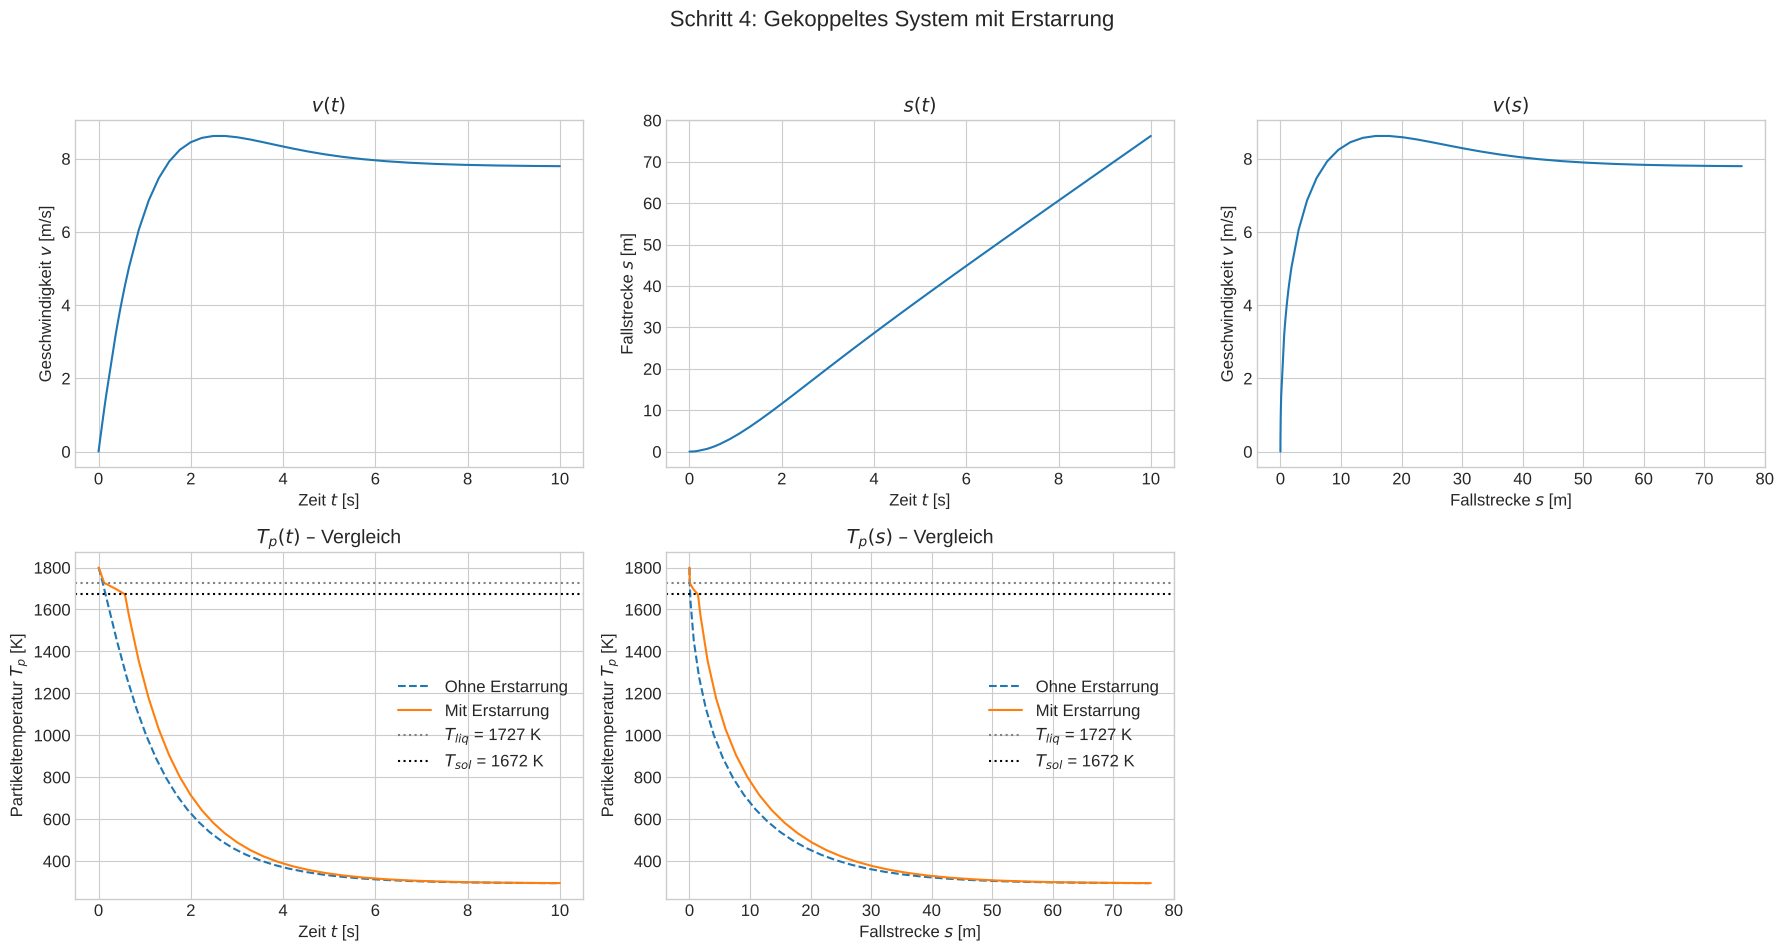

In [5]:
# --- Konstanten für die Erstarrung ---
T_liq = 1727      # Liquidustemperatur [K]
T_sol = 1672      # Solidustemperatur [K]
dh_s = 270000     # Spezifische Erstarrungsenthalpie [J/kg]
c_p_sol = 600     # Wärmekapazität fest [J/(kg*K)]
c_p_liq = 820     # Wärmekapazität flüssig [J/(kg*K)]

def c_p_eff(T_p):
    if T_p > T_liq:
        return c_p_liq
    elif ##########:
        return c_p_sol + dh_s / (T_liq - T_sol)
    else:
        return c_p_sol

# --- ODE-System für Schritt 4 ---
def model_step4(t, y):
    v, T_p, s = y

    # Impulsbilanz (identisch zu Schritt 3)
    rho_f_Tp = rho_gas(T_p)
    eta_f_Tp = eta_gas(T_p)
    Re_p = rho_f_Tp * abs(v) * d_p / eta_f_Tp
    if Re_p > 0:
        c_w = (24 / Re_p) * (1 + 0.15 * Re_p**0.687)
    else:
        c_w = 0
    rho_f_Tf = rho_gas(T_f)
    dv_dt = g * (1 - rho_f_Tf / rho_p) - (3 * c_w * rho_f_Tp) / (4 * d_p * rho_p) * v**2

    # Energiebilanz mit c_p_eff
    T_film = (T_p + T_f) / 2
    Re_film = rho_gas(T_film) * abs(v) * d_p / eta_gas(T_film)
    Pr_film = c_p_gas(T_film) * eta_gas(T_film) / lambda_gas(T_film)
    Nu_film = 2.0 + 0.6 * Re_film**0.5 * Pr_film**(1/3)
    alpha = Nu_film * lambda_gas(T_film) / d_p
    dTp_dt = - (6 * alpha) / (rho_p * c_p_eff(T_p) * d_p) * (T_p - T_f)

    # Wegbilanz
    ds_dt = v

    return [dv_dt, dTp_dt, ds_dt]

# --- Simulation ---
y0_step4 = [0, 1800, 0]
sol_step4 = solve_ivp(##########, t_span_long, y0_step4, rtol=1e-6)

# --- Plotten der Ergebnisse ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Schritt 4: Gekoppeltes System mit Erstarrung', fontsize=16)

# v(t)
axs[0, 0].plot(sol_step4.t, sol_step4.y[0])
axs[0, 0].set_xlabel('Zeit $t$ [s]')
axs[0, 0].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0, 0].set_title('$v(t)$')

# s(t)
axs[0, 1].plot(sol_step4.t, sol_step4.y[2])
axs[0, 1].set_xlabel('Zeit $t$ [s]')
axs[0, 1].set_ylabel('Fallstrecke $s$ [m]')
axs[0, 1].set_title('$s(t)$')

# v(s)
axs[0, 2].plot(sol_step4.y[2], sol_step4.y[0])
axs[0, 2].set_xlabel('Fallstrecke $s$ [m]')
axs[0, 2].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0, 2].set_title('$v(s)$')

# T_p(t) mit Vergleich
axs[1, 0].plot(sol_step3.t, sol_step3.y[1], '--', label='Ohne Erstarrung')
axs[1, 0].plot(sol_step4.t, sol_step4.y[1], label='Mit Erstarrung')
axs[1, 0].axhline(y=T_liq, color='grey', linestyle=':', label=f'$T_{{liq}}$ = {T_liq} K')
axs[1, 0].axhline(y=T_sol, color='black', linestyle=':', label=f'$T_{{sol}}$ = {T_sol} K')
axs[1, 0].set_xlabel('Zeit $t$ [s]')
axs[1, 0].set_ylabel('Partikeltemperatur $T_p$ [K]')
axs[1, 0].set_title('$T_p(t)$ – Vergleich')
axs[1, 0].legend()

# T_p(s) mit Vergleich
axs[1, 1].plot(sol_step3.y[2], sol_step3.y[1], '--', label='Ohne Erstarrung')
axs[1, 1].plot(sol_step4.y[2], sol_step4.y[1], label='Mit Erstarrung')
axs[1, 1].axhline(y=T_liq, color='grey', linestyle=':', label=f'$T_{{liq}}$ = {T_liq} K')
axs[1, 1].axhline(y=T_sol, color='black', linestyle=':', label=f'$T_{{sol}}$ = {T_sol} K')
axs[1, 1].set_xlabel('Fallstrecke $s$ [m]')
axs[1, 1].set_ylabel('Partikeltemperatur $T_p$ [K]')
axs[1, 1].set_title('$T_p(s)$ – Vergleich')
axs[1, 1].legend()

# Leerer Plot für Symmetrie
axs[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Schritt 5: Detaillierte Ansicht der Erstarrung (kurzer Zeitraum)
Um das Erstarrungsplateau genauer zu untersuchen, führen wir die Simulation erneut für einen kürzeren Zeitraum von nur einer Sekunde durch. Dies ermöglicht eine höhere zeitliche Auflösung des Prozesses und macht die Verlangsamung der Abkühlung während des Phasenübergangs deutlicher sichtbar.

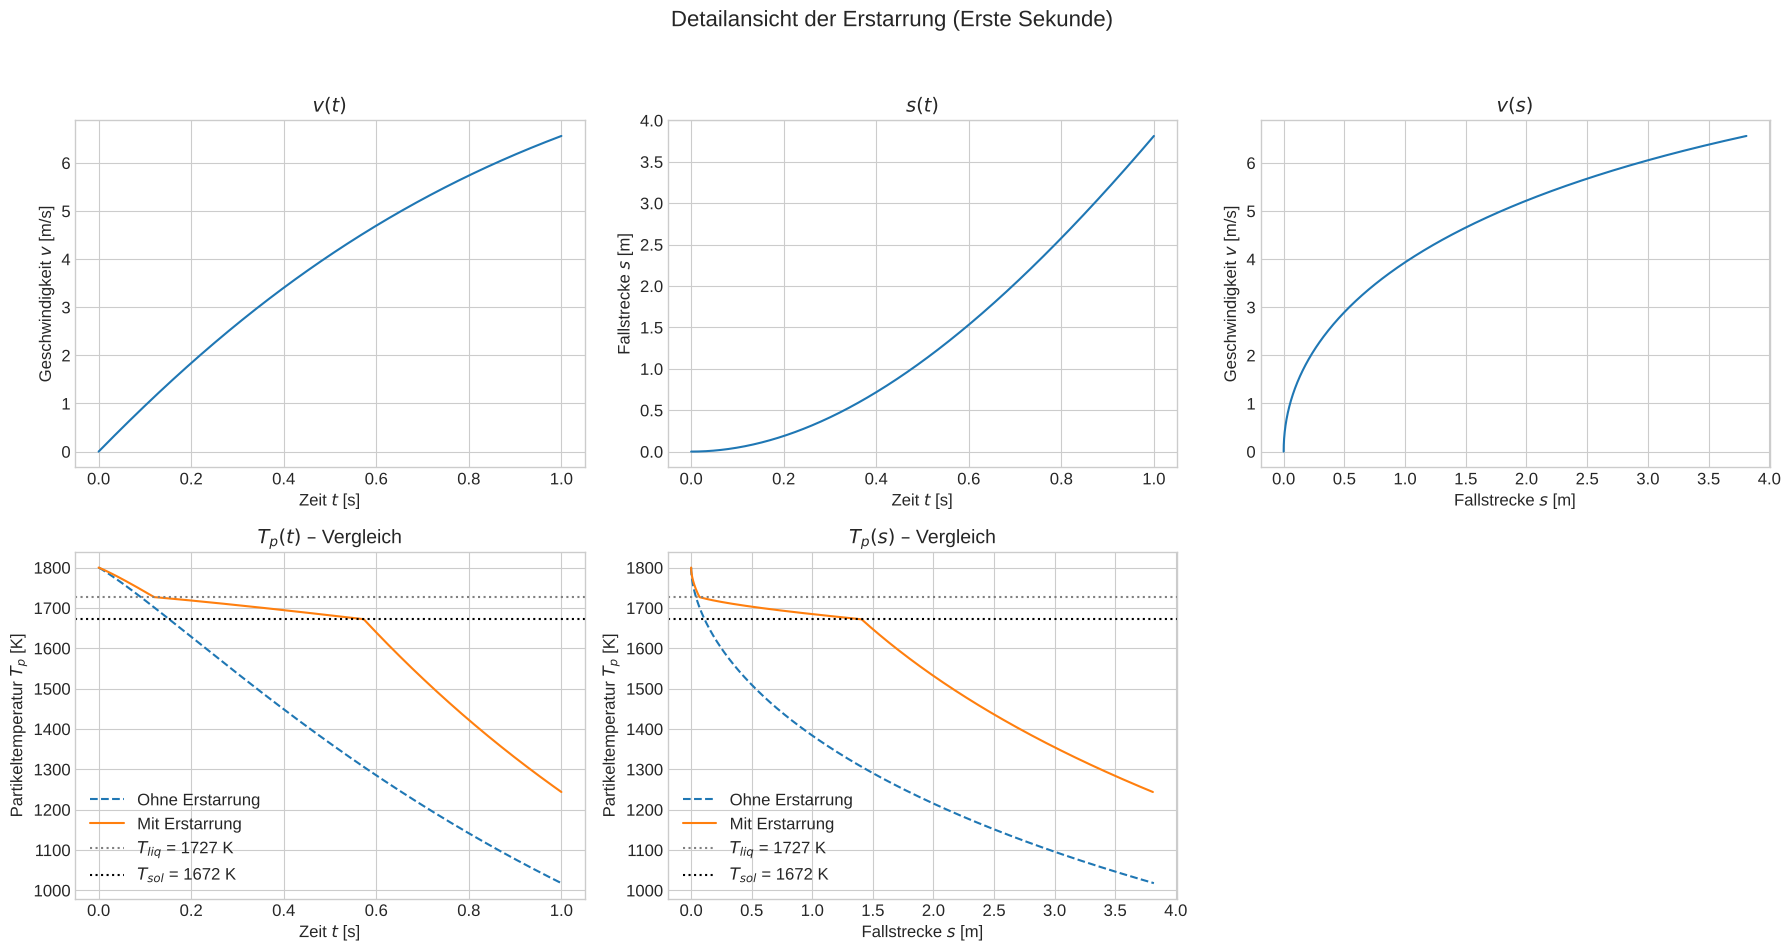

In [6]:
# --- Simulation für einen kurzen Zeitraum (1 Sekunde) ---
t_span_short = [0, 1]
t_eval_short = np.linspace(t_span_short[0], t_span_short[1], 500)  # Höhere Auflösung der Ausgabe

# Simulationen für den Vergleich im kurzen Zeitfenster
sol_step3_short = solve_ivp(model_step3, t_span_short, y0_step3, t_eval=t_eval_short, rtol=1e-6)
sol_step4_short = solve_ivp(model_step4, t_span_short, y0_step4, t_eval=t_eval_short, rtol=1e-6)

# --- Plotten der Ergebnisse für den kurzen Zeitraum ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Detailansicht der Erstarrung (Erste Sekunde)', fontsize=16)

# v(t)
axs[0, 0].plot(sol_step4_short.t, sol_step4_short.y[0])
axs[0, 0].set_xlabel('Zeit $t$ [s]')
axs[0, 0].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0, 0].set_title('$v(t)$')

# s(t)
axs[0, 1].plot(sol_step4_short.t, sol_step4_short.y[2])
axs[0, 1].set_xlabel('Zeit $t$ [s]')
axs[0, 1].set_ylabel('Fallstrecke $s$ [m]')
axs[0, 1].set_title('$s(t)$')

# v(s)
axs[0, 2].plot(sol_step4_short.y[2], sol_step4_short.y[0])
axs[0, 2].set_xlabel('Fallstrecke $s$ [m]')
axs[0, 2].set_ylabel('Geschwindigkeit $v$ [m/s]')
axs[0, 2].set_title('$v(s)$')

# T_p(t) mit Vergleich
axs[1, 0].plot(sol_step3_short.t, sol_step3_short.y[1], '--', label='Ohne Erstarrung')
axs[1, 0].plot(sol_step4_short.t, sol_step4_short.y[1], label='Mit Erstarrung')
axs[1, 0].axhline(y=T_liq, color='grey', linestyle=':', label=f'$T_{{liq}}$ = {T_liq} K')
axs[1, 0].axhline(y=T_sol, color='black', linestyle=':', label=f'$T_{{sol}}$ = {T_sol} K')
axs[1, 0].set_xlabel('Zeit $t$ [s]')
axs[1, 0].set_ylabel('Partikeltemperatur $T_p$ [K]')
axs[1, 0].set_title('$T_p(t)$ – Vergleich')
axs[1, 0].legend()

# T_p(s) mit Vergleich
axs[1, 1].plot(sol_step3_short.y[2], sol_step3_short.y[1], '--', label='Ohne Erstarrung')
axs[1, 1].plot(sol_step4_short.y[2], sol_step4_short.y[1], label='Mit Erstarrung')
axs[1, 1].axhline(y=T_liq, color='grey', linestyle=':', label=f'$T_{{liq}}$ = {T_liq} K')
axs[1, 1].axhline(y=T_sol, color='black', linestyle=':', label=f'$T_{{sol}}$ = {T_sol} K')
axs[1, 1].set_xlabel('Fallstrecke $s$ [m]')
axs[1, 1].set_ylabel('Partikeltemperatur $T_p$ [K]')
axs[1, 1].set_title('$T_p(s)$ – Vergleich')
axs[1, 1].legend()

# Leerer Plot für Symmetrie
axs[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()